# Part 2. 딥러닝 몸풀기  
Chapter 2. 당뇨병 진행도 예측하기  


dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log 

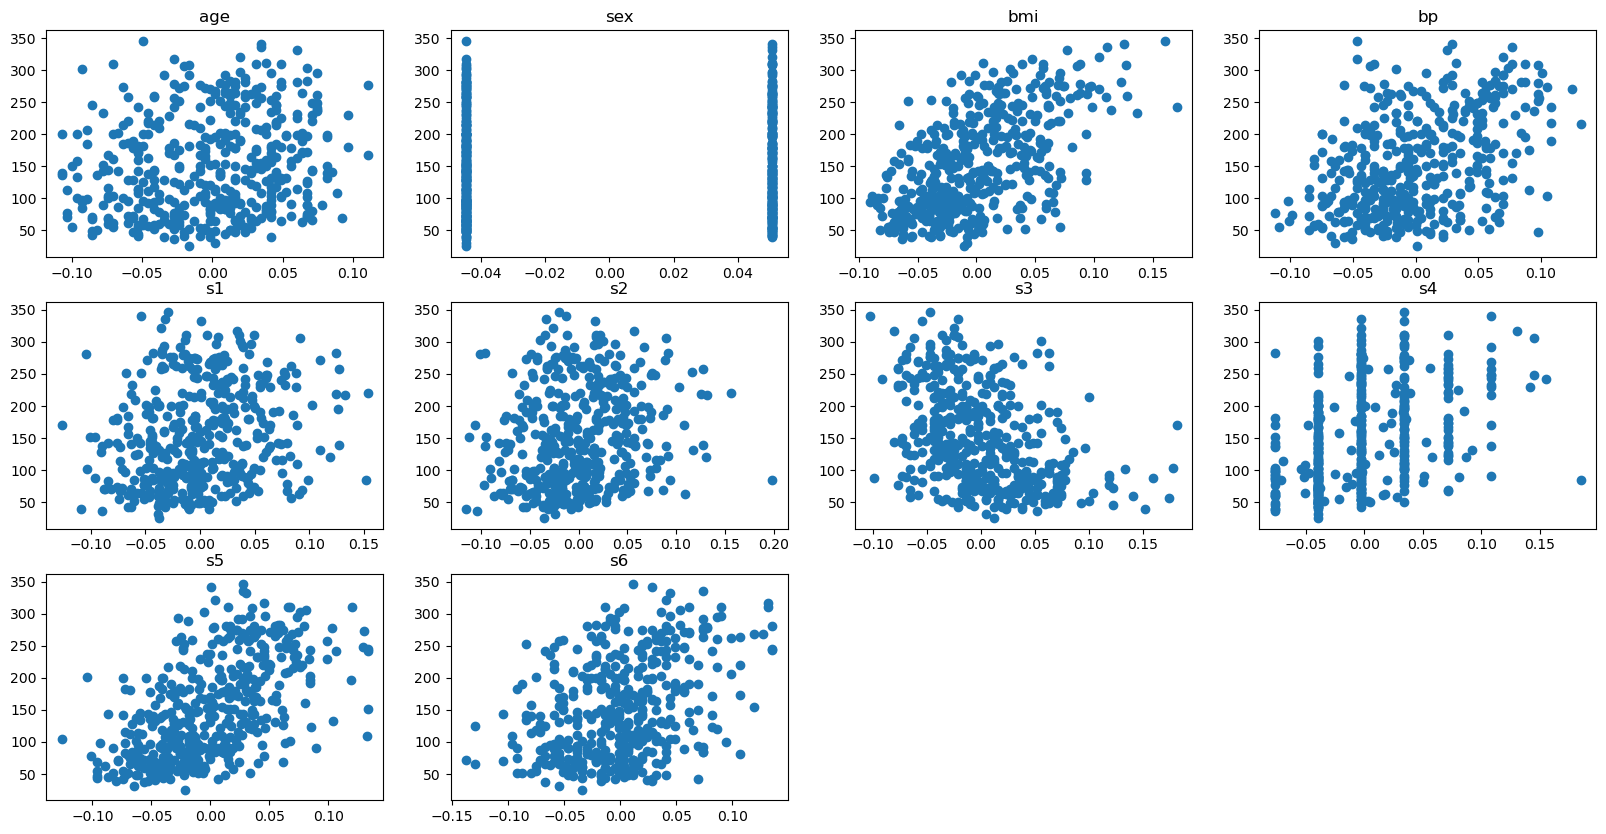

In [8]:
# 2.1 데이터 살펴보기

from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_diabetes()
print(dataset.keys())
print(dataset.DESCR)

print(dataset)

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

print(df.head())



plt.figure(figsize=(20,10))
for i in range(10):
  plt.subplot(3, 4, i+1)
  plt.scatter(df.iloc[:, i], df['target'])
  plt.title(df.columns[i])
plt.show()

In [ ]:
# 2.2 모델 구현 및 학습

import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

X = torch.FloatTensor(df.iloc[:, :10].values)
Y = torch.FloatTensor(df['target'].values).reshape(-1, 1)

batch_size = 64
learning_rate = 1e-4
epochs = 30000

optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

for epoch in range(epochs):

  # 배치 설명
  for i in range(len(X) // batch_size):  # // 는 정수만 반환
    start = i*batch_size
    end = start + batch_size

    x = X[start:end]
    y = Y[start:end]

    optimizer.zero_grad()

    pred_y = model(x)

    loss = nn.MSELoss()(pred_y, y)
    loss.backward()
    optimizer.step()

  if epoch % 2000 == 0:
    print("epoch:", epoch, "loss:", loss.item())

epoch: 0 loss: 33404.46875
epoch: 2000 loss: 3223.87646484375
epoch: 4000 loss: 2993.555908203125
epoch: 6000 loss: 2769.3994140625
epoch: 8000 loss: 2459.884033203125
epoch: 10000 loss: 2073.515625
epoch: 12000 loss: 1684.5469970703125
epoch: 14000 loss: 1168.122802734375
epoch: 16000 loss: 979.9071044921875
epoch: 18000 loss: 880.4888305664062
epoch: 20000 loss: 673.6282958984375
epoch: 22000 loss: 575.7836303710938
epoch: 24000 loss: 1395.7130126953125
epoch: 26000 loss: 764.5355224609375
epoch: 28000 loss: 496.245849609375


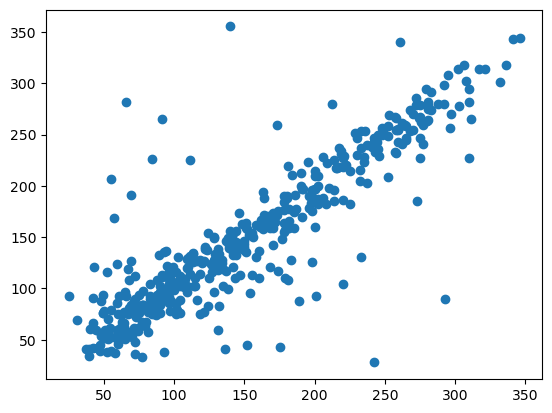

In [5]:
# 2.3 모델 성능 평가

import matplotlib.pyplot as plt

pred = model(torch.FloatTensor(X))
plt.scatter(Y.numpy(), pred.reshape(1, -1).clone().detach().numpy())

MAE: 20.699329376220703 RMSE: 36.65531539916992
MAE: 151.9659423828125 RMSE: 170.36326599121094


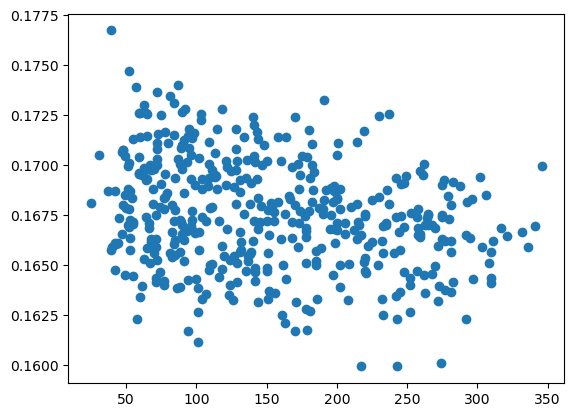

In [6]:
pred = model(torch.FloatTensor(X))

mae = (pred - Y).abs().mean()
rmse = ((pred - Y) ** 2).mean().sqrt()

print("MAE:", mae.item(), "RMSE:", rmse.item())

untrained_model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

pred = untrained_model(torch.FloatTensor(X))
plt.scatter(Y.numpy(), pred.reshape(1, -1).clone().detach().numpy())

pred = untrained_model(torch.FloatTensor(X))

mae = (pred - Y).abs().mean()
rmse = ((pred - Y) ** 2).mean().sqrt()

print("MAE:", mae.item(), "RMSE:", rmse.item())

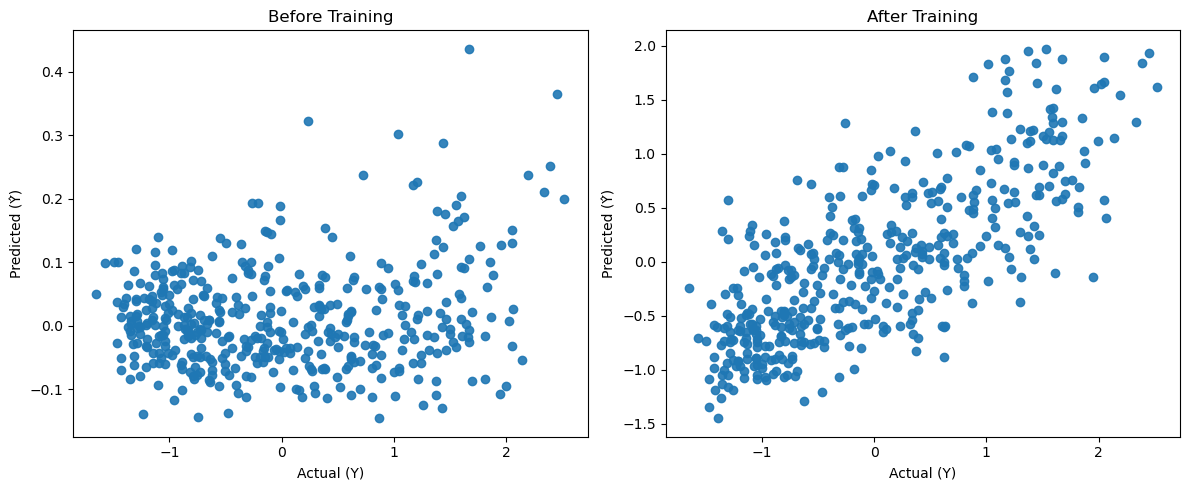

In [10]:
# 강사님 카페 소스: https://cafe.naver.com/hamminglab/22128

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler



# 데이터 로드
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target.reshape(-1, 1)

# 표준화
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(X)
y = scaler_y.fit_transform(y)

# Tensor로 변환
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

# 모델 정의
model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

# 학습 전 예측 저장
with torch.no_grad():
    pred_before = model(X_tensor)

# 손실 함수 및 옵티마이저 설정
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 학습 루프
for epoch in range(1000):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()

# 학습 후 예측 저장
with torch.no_grad():
    pred_after = model(X_tensor)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_tensor.numpy(), pred_before.numpy(), alpha=0.9)
axes[0].set_title("Before Training")
axes[0].set_xlabel("Actual (Y)")
axes[0].set_ylabel("Predicted (Ŷ)")

axes[1].scatter(y_tensor.numpy(), pred_after.numpy(), alpha=0.9)
axes[1].set_title("After Training")
axes[1].set_xlabel("Actual (Y)")
axes[1].set_ylabel("Predicted (Ŷ)")

plt.tight_layout()
plt.show()